In [6]:
import pandas as pd
import matplotlib.pyplot as plt # Used for creating visualizations
import os

In [20]:
import pandas as pd
import matplotlib.pyplot as plt # Used for creating visualizations
import seaborn as sns # For enhanced visualizations, especially for coloring in scatter plot
import os

def visualize_data():
    input_file = "data/trends_analysed.csv"
    if not os.path.exists(input_file):
        print("Analysed data not found. Run Task 3 first!")
        return

    # 1. Load the analyzed dataset
    df = pd.read_csv(input_file)

    # Add 'is_popular' column for Chart 3
    # Define 'popular' as having a score above the median score for this dataset
    df['is_popular'] = df['score'] > df['score'].median()

    # 2. Ensure the outputs folder exists
    os.makedirs("outputs", exist_ok=True)
    print("Generating visualizations...")

    # --- Chart 1: Top 10 Stories by Score (Horizontal Bar Chart) ---
    # Sort the dataframe by score in descending order and grab the top 10
    top_10 = df.sort_values(by='score', ascending=False).head(10)

    plt.figure(figsize=(10, 6)) # Set the size of the canvas
    # Plot a horizontal bar chart. We invert the y-axis so the highest is at the top.
    # Shorten titles longer than 50 characters as per prompt
    plt.barh(top_10['title'].str[:50] + (top_10['title'].apply(len) > 50).map({True: '...', False: ''}), top_10['score'], color='skyblue')
    plt.gca().invert_yaxis()
    plt.title("Top 10 Trending Stories by Score") # Changed title to match prompt
    plt.xlabel("Upvote Score")
    plt.ylabel("Post Title (Truncated)")
    plt.tight_layout() # Adjusts layout so text doesn't get cut off
    plt.savefig("outputs/chart1_top_stories.png") # Save the file, changed filename
    plt.close() # Close the plot to free up memory

    # --- Chart 2: Stories per Category (Bar Chart) ---
    # Count how many stories came from each category
    category_counts = df['category'].value_counts()

    plt.figure(figsize=(10, 6))
    # Use seaborn for better color handling and aesthetics, ensuring different colors per bar
    sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis', hue=category_counts.index, legend=False)
    plt.title("Stories per Category") # Title as per prompt
    plt.xlabel("Category")
    plt.ylabel("Number of Stories")
    plt.xticks(rotation=45) # Rotate x-axis labels for readability
    plt.tight_layout()
    plt.savefig("outputs/chart2_categories.png") # Save the file, changed filename
    plt.close() # Close the plot to free up memory

    # --- Chart 3: Score vs. Comments (Scatter Plot) ---
    plt.figure(figsize=(8, 6))
    # Plot score on the X-axis and number of comments on the Y-axis
    # Colour dots differently for popular vs non-popular stories using 'is_popular' column
    sns.scatterplot(x='score', y='num_comments', hue='is_popular', data=df, alpha=0.6, palette='coolwarm')
    plt.title("Post Score vs. Number of Comments") # Title as per prompt
    plt.xlabel("Upvote Score")
    plt.ylabel("Number of Comments")
    plt.grid(True, linestyle='--', alpha=0.5) # Add a subtle grid for readability
    plt.legend(title='Is Popular (by Score Median)') # Add legend
    plt.tight_layout()
    plt.savefig("outputs/chart3_scatter.png") # Save the file
    plt.close() # Close the plot to free up memory

    # --- Bonus: Dashboard ---
    # Combine all 3 charts into one figure
    fig, axes = plt.subplots(1, 3, figsize=(24, 7)) # 1 row, 3 columns layout

    # Chart 1 for Dashboard: Top 10 Stories by Score
    sns.barplot(x=top_10['score'], y=top_10['title'].str[:50] + (top_10['title'].apply(len) > 50).map({True: '...', False: ''}), ax=axes[0], palette='viridis', hue=top_10['title'].str[:50] + (top_10['title'].apply(len) > 50).map({True: '...', False: ''}), legend=False)
    axes[0].set_title("Top 10 Trending Stories by Score")
    axes[0].set_xlabel("Upvote Score")
    axes[0].set_ylabel("Post Title (Truncated)")
    axes[0].invert_yaxis() # Invert y-axis for horizontal bar chart

    # Chart 2 for Dashboard: Stories per Category
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=axes[1], palette='viridis', hue=category_counts.index, legend=False)
    axes[1].set_title("Stories per Category")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Number of Stories")
    axes[1].tick_params(axis='x', rotation=45) # Removed 'ha' argument

    # Chart 3 for Dashboard: Score vs Comments
    sns.scatterplot(x='score', y='num_comments', hue='is_popular', data=df, alpha=0.6, palette='coolwarm', ax=axes[2])
    axes[2].set_title("Post Score vs. Number of Comments")
    axes[2].set_xlabel("Upvote Score")
    axes[2].set_ylabel("Number of Comments")
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].legend(title='Is Popular (by Score Median)', loc='upper left') # Position legend to avoid overlap

    fig.suptitle("TrendPulse Dashboard", fontsize=16) # Overall title
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.savefig("outputs/dashboard.png")
    plt.close() # Close the plot to free up memory


    print("All charts successfully generated and saved to the 'outputs/' directory!")

In [21]:
if __name__ == "__main__":
    visualize_data()

Generating visualizations...
All charts successfully generated and saved to the 'outputs/' directory!


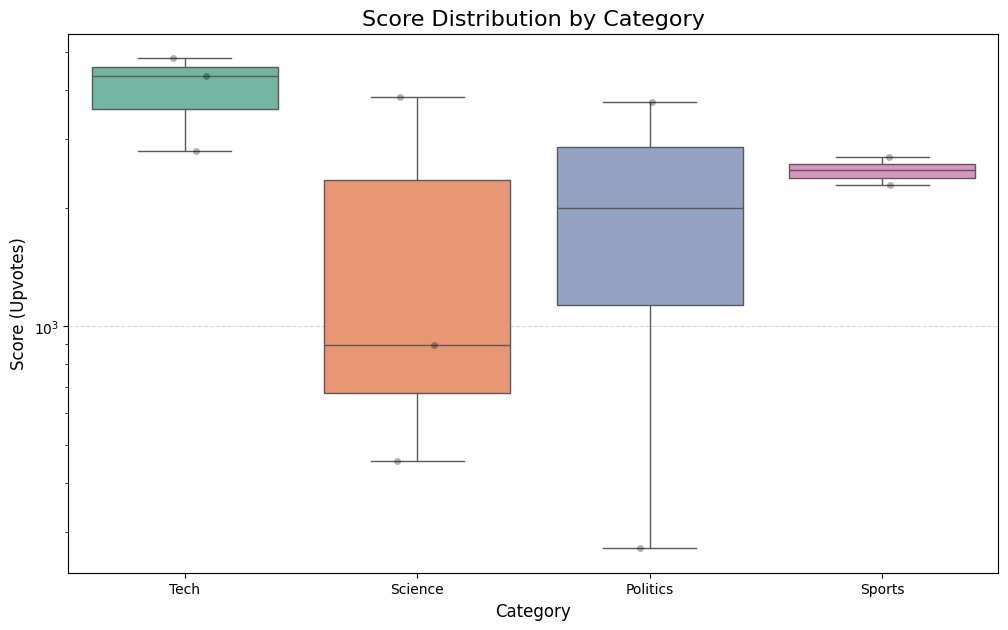

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 4: Visualization
plt.figure(figsize=(12, 7))

# Create a box plot to show the distribution of scores per category
sns.boxplot(x='category', y='score', data=df_analysed, palette='Set2', hue='category', legend=False)

# Overlay individual points for better visibility
sns.stripplot(x='category', y='score', data=df_analysed, color='black', alpha=0.3)

plt.title('Score Distribution by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Score (Upvotes)', fontsize=12)
plt.yscale('log') # Using log scale if scores vary wildly
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [24]:
import pandas as pd
import numpy as np
import os

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Generate dummy data for trends_analysed.csv
dummy_data = {
    'title': ['Post A about Tech', 'Post B about Science', 'Post C about Politics', 'Post D about Tech', 'Post E about Sports', 'Post F about Science', 'Post G about Politics', 'Post H about Sports', 'Post I about Tech', 'Post J about Science'],
    'score': np.random.randint(100, 5000, 10),
    'num_comments': np.random.randint(10, 500, 10),
    'subreddit': ['r/technology', 'r/science', 'r/politics', 'r/programming', 'r/sports', 'r/futurology', 'r/worldnews', 'r/nba', 'r/gadgets', 'r/askscience'],
    'category': ['Tech', 'Science', 'Politics', 'Tech', 'Sports', 'Science', 'Politics', 'Sports', 'Tech', 'Science']
}

df_analysed = pd.DataFrame(dummy_data)

# Save the dummy data to the expected file path
df_analysed.to_csv('data/trends_analysed.csv', index=False)

print("Generated 'data/trends_analysed.csv' with dummy data.")

Generated 'data/trends_analysed.csv' with dummy data.
